In [21]:
from google.colab import files

uploaded = files.upload()

Saving consumos energia ZC atlantis 2026.xlsx to consumos energia ZC atlantis 2026.xlsx


In [25]:
list(uploaded.keys())

[]

In [26]:
['consumos energia ZC atlantis 2026.xlsx']

['consumos energia ZC atlantis 2026.xlsx']

In [28]:
import pandas as pd

df = pd.read_excel("consumos energia ZC atlantis 2026.xlsx")

df.head()

,mes,consumo activa kwh
0,2026-01-01,328966
1,2026-02-01,306876
2,2026-03-01,342008
3,2026-04-01,325350
4,2026-05-01,342350


In [29]:
print(df.columns)


Index(['mes', 'consumo activa  kwh '], dtype='object')


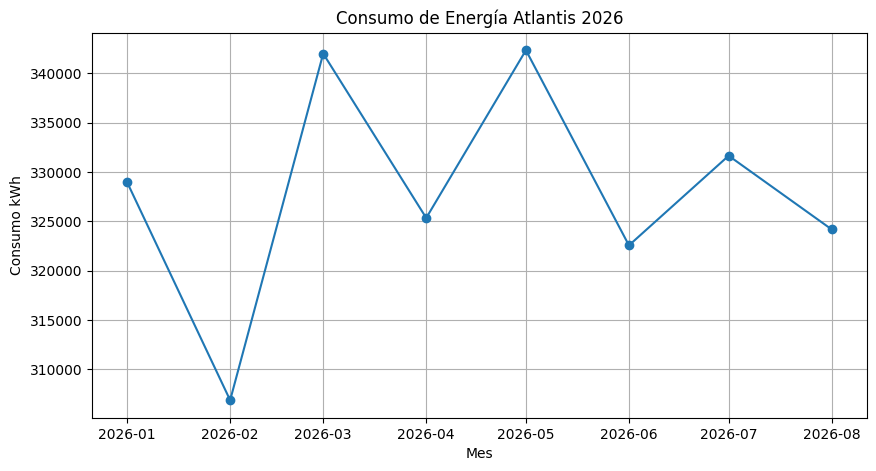

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df["mes"],
    df["consumo activa  kwh "],
    marker="o"
)

plt.title("Consumo de Energía Atlantis 2026")
plt.xlabel("Mes")
plt.ylabel("Consumo kWh")
plt.grid(True)

plt.show()

In [31]:
mayor = df.loc[df["consumo activa  kwh "].idxmax()]
menor = df.loc[df["consumo activa  kwh "].idxmin()]

print("Mayor consumo")
print(mayor["mes"])
print(mayor["consumo activa  kwh "])

print()

print("Menor consumo")
print(menor["mes"])
print(menor["consumo activa  kwh "])

Mayor consumo
2026-05-01 00:00:00
342350

Menor consumo
2026-02-01 00:00:00
306876


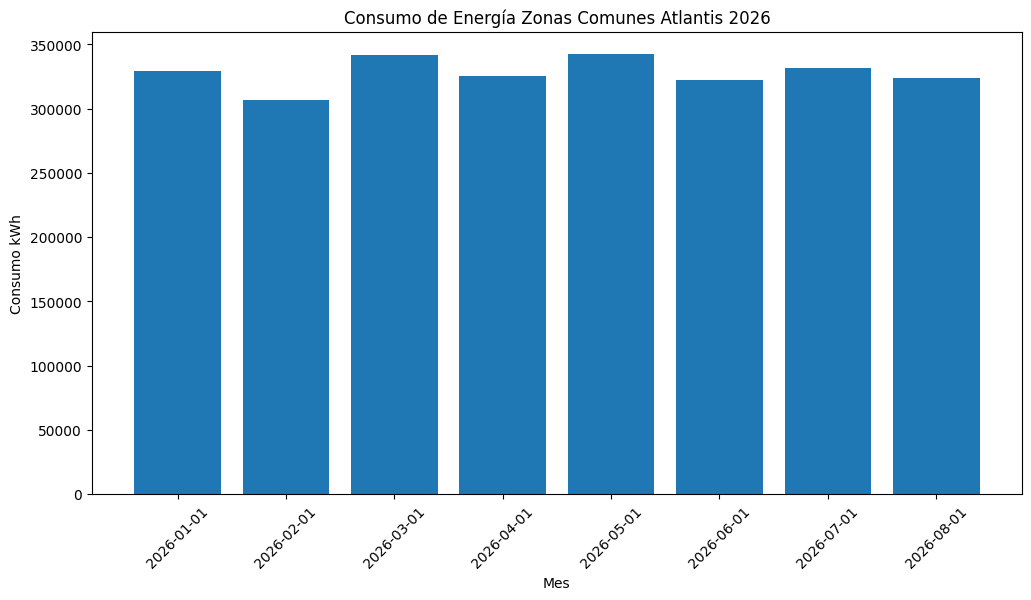

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    df["mes"].astype(str),
    df["consumo activa  kwh "]
)

plt.title("Consumo de Energía Zonas Comunes Atlantis 2026")
plt.xlabel("Mes")
plt.ylabel("Consumo kWh")

plt.xticks(rotation=45)

plt.show()

In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np

df["numero_mes"] = np.arange(len(df))

X = df[["numero_mes"]]
y = df["consumo activa  kwh "]

modelo = LinearRegression()

modelo.fit(X, y)

prediccion = modelo.predict([[len(df)]])

print("Predicción septiembre 2026:")
print(round(prediccion[0], 0), "kWh")

Predicción septiembre 2026:
330629.0 kWh


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
from sklearn.metrics import r2_score

predicciones = modelo.predict(X)

r2 = r2_score(y, predicciones)

print("R2 =", round(r2,3))

R2 = 0.016


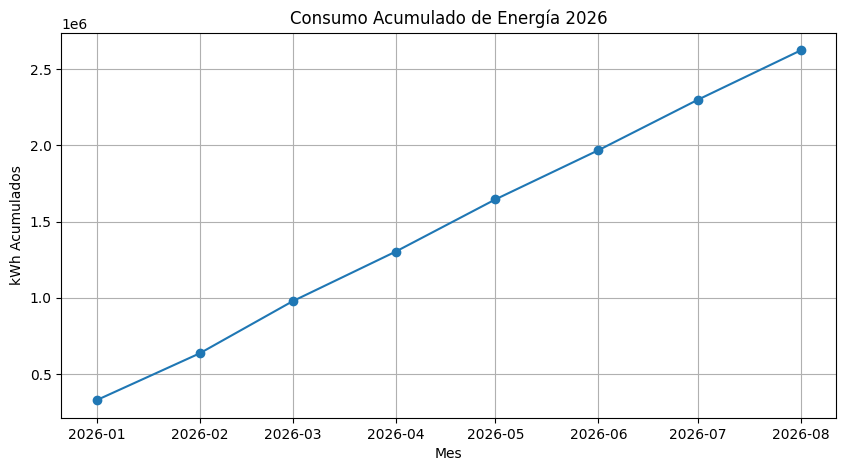

In [35]:
df["consumo_acumulado"] = df["consumo activa  kwh "].cumsum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["mes"], df["consumo_acumulado"], marker="o")
plt.title("Consumo Acumulado de Energía 2026")
plt.xlabel("Mes")
plt.ylabel("kWh Acumulados")
plt.grid(True)
plt.show()